# Load Functions and Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.fft import fft, fftfreq
import itertools
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.metrics import auc
from tkinter.filedialog import askdirectory, askopenfilename 
import tkinter as tk
from ipywidgets import interact, widgets, fixed, interactive, HBox, Layout
import pandas as pd
import numpy as np
import os

# Custom Functions
from FunctionsProcess import *

ModuleNotFoundError: No module named 'numpy'

# Select directory with the data

In [26]:
root = tk.Tk()
# root.withdraw()
root.attributes('-topmost',True)
root.iconify()

test = askopenfilename(parent=root, initialdir='C:/IBECPostDocDrive/2025_10_06_MiceScripts_Vicent')

root.destroy()


df = pd.read_excel(test)

exnall = np.array(df['Unnamed: 0'][1::])
drsall = np.array(df['Unnamed: 1'][1::])
stsall = np.array(df['Unnamed: 2'][1::])
stiall = np.array(df['Unnamed: 3'][1::])
soiall = np.array(df['Unnamed: 4'][1::])
drsexp = getExpDirs(drsall)

In [27]:
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ID,FilePath,StartScan,StartInject,StopInject
1,2276-1,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,9,28,40
2,2276-2,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,9,29,41
3,2276-3,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,9,31,43
4,2276-4,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,9,25,37
5,2276-5,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,8,18,30


# Process Data

In [28]:
# DEFINE A LINE BROADENING FACTOR!!!
LB = 4


# This block start the processing of the raw spectral data from the MRI
# if the folder selected in the previous block contains the right data. 
# if this block launches an error is probably because the folder does not contain spectral data to process.

metDatAll = {}
datAll= {}

for i in range(len(drsexp)):
    
    indx = [k for k in range(len(drsexp[i])) if drsexp[i][k].find('\\')==0]
    foldPath = drsexp[i][0:indx[-1]]
    foldNum = drsexp[i][indx[-1]+1:]
    
    rot, RECO_ft_mode, bw, bwc, ACQ_repetition_time, ACQ_Size, NR, bwHz = getMetaDat(foldPath, foldNum)
    # Last Argument is Line broadening Factor
    ppms, futmag, fut, co3 = ProcDat(foldPath, foldNum, NR, ACQ_Size, rot, bwc, bw, LB)
    
    
    metDatAll[drsexp[i]] = {
                            "foldPath": foldPath,
                            "foldNum": foldNum,
                            "rot": rot,
                            "RECO_ft_mode": RECO_ft_mode,
                            "bw": bw,
                            "bwc": bwc,
                            "ACQ_repetition_time": ACQ_repetition_time,
                            "ACQ_Size": ACQ_Size,
                            "NR": NR,
                            "bwHz": bwHz
                           }
    datAll[drsexp[i]] = {
                            "ppms": ppms,
                            "futmag": futmag,
                            "fut": fut,
                            "co3": co3
                        }
    
ini_All, ene_All, SNRs_All, datAll2 = corPpm(drsexp, datAll)    

# Plot FID

In [ ]:
interFIDs(datAll, drsexp)

interactive(children=(Dropdown(description='Exp.:', layout=Layout(width='1000px'), options=('C:\\Users\\Vicent…

# Plot magnitude spectra

In [ ]:
interMags(datAll2, drsexp)

interactive(children=(Dropdown(description='Exp.:', layout=Layout(width='1000px'), options=('C:\\Users\\Vicent…

# Plot Max SNR Per Experiment

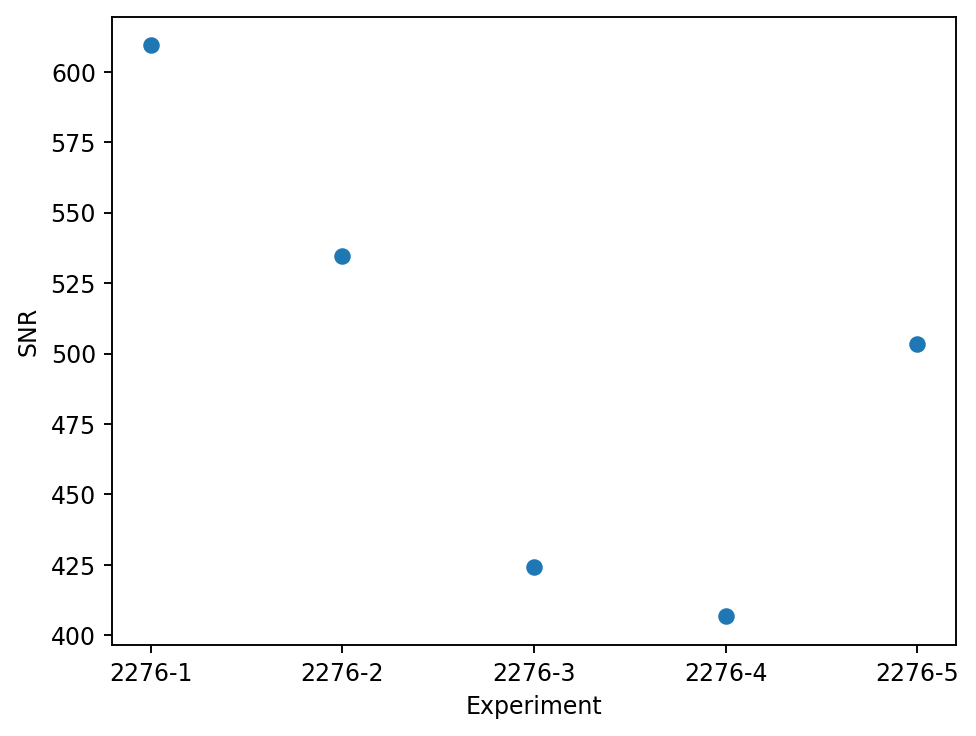

In [32]:
# ADD TO SAVE THIS PLOT

plt.figure(dpi=170)
plt.scatter(range(len(drsexp)), [np.max(SNRs_All[drsexp[i]]) for i in range(len(drsexp))])
plt.ylabel("SNR")
plt.xlabel("Experiment")
plt.xticks(range(len(drsexp)), exnall)#, rotation='vertical')

plt.savefig(foldPath+'/PlotIntersSumUp.png')
plt.savefig(foldPath+'/PlotIntersSumUp.svg')


plt.show()

# Plot Sum of All Spectra Acquired

In [34]:

for i in range(len(drsexp)):

    ini_All[drsexp[i]]

    tmp1 = datAll2[drsexp[i]]['futmag_cor'][ini_All[drsexp[i]]:ene_All[drsexp[i]]+1]

    datAll2[drsexp[i]]['sumup'] = np.sum(tmp1, axis=0)

interSumUp(datAll2, drsexp)


interactive(children=(Dropdown(description='Exp.:', layout=Layout(width='1000px'), options=('C:\\Users\\Vicent…

# Plot Stack of All Spectra Acquired

### Stack 3D

In [ ]:
interStack3D(datAll2, drsexp, ini_All ,ene_All, exnall, grad=False)

interactive(children=(Dropdown(description='Sub.Exp.:', options=(0, 1, 2, 3, 4), value=0), IntSlider(value=36,…

### Stack 2D

In [50]:
interStack2D(datAll2, drsexp, ini_All ,ene_All, exnall)

interactive(children=(Dropdown(description='Sub.Exp.:', options=(1, 2, 3, 4, 5), value=1), IntRangeSlider(valu…

# Integrals

Bicarbonate C1 (161 ppm)

Pyruvate C1 (171.1 ppm)

Alanine C1 (176.5 ppm)

Pyruvate-hydrate C1 (179.5 ppm)

Lactate C1 (183.4 ppm)

## Selection of Integral Regions

### STOP POINT (IMPORTANT!!!!)

In [ ]:
integralExtract(datAll2, drsexp, ini_All ,ene_All, exnall)

interactive(children=(FloatRangeSlider(value=(-184.5, -181.5), description='Lac', layout=Layout(width='1400px'…

# Integrals

## Sum Up
### The integral areas will be calculated based on this graph

In [56]:
IntsAll, intersAll = getIntsAll(drsexp, datAll2)
interSumUpInts(datAll2, drsexp, IntsAll, intersAll)

interactive(children=(Dropdown(description='Exp.:', layout=Layout(width='1000px'), options=('C:\\Users\\Vicent…

## Integrals Over Time


In [ ]:
allDatsTemp = getTempIntsAll(datAll2, drsexp, IntsAll)
interTimssInts(drsexp, intersAll, allDatsTemp)

interactive(children=(Dropdown(description='Exp.:', layout=Layout(width='1000px'), options=('C:\\Users\\Vicent…

# Save Data in Excel (and CSV)

In [58]:
saveDatAll(drsexp, ini_All, ene_All, SNRs_All, intersAll, test, exnall,drsall,stsall,stiall,soiall)

,ID,FilePath,StartScan,StartInject,StopInject,13C_Folder,ini,ene,SNR,Pyr,Lac,Ala,BiC,Pyr/Tot13C,Lac/Tot13C,Ala/Tot13C,BiC/Tot13C
0,2276-1,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,9,28,40,4,5,25,609.381424,2655890011.441359,758869163.340007,771456179.120441,74408995.625732,0.155963,0.044563,0.045303,0.00437
1,2276-2,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,9,29,41,4,5,23,534.601989,2435105691.298466,720566447.035653,678102746.720114,85648332.073071,0.142998,0.042314,0.03982,0.00503
2,2276-3,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,9,31,43,3,6,25,424.283421,1401726626.752109,463201226.433166,432095437.292287,41996290.898688,0.082314,0.027201,0.025374,0.002466
3,2276-4,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,9,25,37,3,4,23,406.722173,3086251150.957908,486274011.08015,426730359.698581,96858133.446244,0.181235,0.028556,0.025059,0.005688
4,2276-5,C:\Users\Vicent\OneDrive - IBEC\MRI ANALYSIS\M...,8,18,30,3,3,38,503.296173,1431115319.318371,480751097.147942,465618996.844484,36326128.284143,0.08404,0.028231,0.027343,0.002133


# -------------------------------------- THE END --------------------------------------